# Ablation — 2D Matrix Quantization Bitwidth

Sweeps `matrix_quant_bits` ∈ {16, 8, 6, 4} (1 seed).

| config | meaning |
|---|---|
| `bits = 16` | no quantization — 2D matrices stored as fp16 (passthrough) |
| `bits = 8` | baseline int8 per-row quantization (±127) |
| `bits = 6` | int6 per-row quantization (±31) stored in int8 container |
| `bits = 4` | int4 per-row quantization (±7) stored in int8 container |

This ablation isolates the effect of quantization bitwidth on the **2D weight matrices** (attention Q/K/V/proj and MLP fc/proj), which make up the bulk of the model's parameters. All other quantization settings remain unchanged: control tensors stay in fp32, small tensors (<65 536 elements) stay in fp16. Training is identical across all configs — only the post-training quantization changes.

The key metrics are:
- **Round-trip BPB** (`final_val_bpb`): the BPB after quantize → compress → decompress → dequantize → evaluate.
- **Delta (Δ)**: the BPB increase caused by quantization, i.e. `round_trip_bpb − fp32_bpb`.
- **Compressed file size**: the zlib-compressed model artifact in bytes.

Since training is the same for all runs, differences in BPB come entirely from quantization damage.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import wandb
import importlib
import utils as utils
importlib.reload(utils)
from utils import apply_style, get_deep_palette

apply_style(force=True)
PALETTE = get_deep_palette()

ENTITY  = "the-golfers"
PROJECT = "ml_ai_project"

api = wandb.Api()

# Human-readable labels and display order
BITS_ORDER  = [16, 8, 6, 4]
BITS_LABELS = {
    16: "fp16 (no quant)",
    8:  "int8 (baseline)",
    6:  "int6",
    4:  "int4",
}
BITS_COLORS = {b: PALETTE[i] for i, b in enumerate(BITS_ORDER)}

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from C:\Users\matte\_netrc.


## Original Baseline (3 seeds, reference)

In [2]:
BASELINE_PREFIX = "golf_baseline_matteo_new"

baseline_runs = list(api.runs(
    f"{ENTITY}/{PROJECT}",
    filters={"display_name": {"$regex": f"^{BASELINE_PREFIX}"}},
))

baseline_rows = []
for run in baseline_runs:
    s = run.summary._json_dict
    baseline_rows.append({
        "seed":             run.config.get("seed"),
        "final_val_bpb":    s.get("final_val_bpb"),
        "final_val_loss":   s.get("final_val_loss"),
    })

df_base = pd.DataFrame(baseline_rows).sort_values("seed").reset_index(drop=True)
BASE_BPB_MEAN = df_base["final_val_bpb"].mean()
BASE_BPB_STD  = df_base["final_val_bpb"].std()

print("=" * 50)
print("ORIGINAL BASELINE  (3 seeds)")
print("=" * 50)
print(df_base.to_string(index=False))
print(f"\nfinal_val_bpb : {BASE_BPB_MEAN:.4f} ± {BASE_BPB_STD:.4f}")
print("=" * 50)

ORIGINAL BASELINE  (3 seeds)
 seed  final_val_bpb  final_val_loss
   42       1.311341        2.214145
   42       1.311540        2.214480
  123       1.308945        2.210099
  123       1.308339        2.209076
 1337            NaN             NaN
 1337       1.310012        2.211900
 1337       1.310216        2.212246

final_val_bpb : 1.3101 ± 0.0013


## Ablation — 2D Matrix Quantization Bitwidth

In [3]:
ABL_PREFIX = "golf_2d_matrices_quantization_ablation"

abl_runs = list(api.runs(
    f"{ENTITY}/{PROJECT}",
    filters={"display_name": {"$regex": f"^{ABL_PREFIX}"}},
))

rows = []
for run in abl_runs:
    s   = run.summary._json_dict
    cfg = run.config
    bits = cfg.get("matrix_quant_bits", 8)

    # fp32 BPB: last val_bpb logged during training (before quantization)
    hist = run.history(keys=["_step", "val_bpb"], pandas=True)
    fp32_bpb = hist["val_bpb"].dropna().iloc[-1] if not hist.empty else None

    rows.append({
        "run_name":          run.name,
        "matrix_quant_bits": bits,
        "label":             BITS_LABELS.get(bits, str(bits)),
        "seed":              cfg.get("seed"),
        "fp32_val_bpb":      fp32_bpb,
        "final_val_bpb":     s.get("final_val_bpb"),
        "final_val_loss":    s.get("final_val_loss"),
        "quant_file_bytes":  s.get("quant_file_bytes"),
    })

df = (
    pd.DataFrame(rows)
    .assign(bits_order=lambda d: d["matrix_quant_bits"].map({v: i for i, v in enumerate(BITS_ORDER)}))
    .sort_values("bits_order")
    .reset_index(drop=True)
    .drop(columns="bits_order")
)

# Compute delta (quantization damage)
df["delta_bpb"] = df["final_val_bpb"] - df["fp32_val_bpb"]

df

,run_name,matrix_quant_bits,label,seed,fp32_val_bpb,final_val_bpb,final_val_loss,quant_file_bytes,delta_bpb
0,golf_2d_matrices_quantization_ablation_seed1337,8,int8 (baseline),1337,1.306432,1.310132,2.212102,15768886,0.003700
1,golf_2d_matrices_quantization_ablation_seed42,8,int8 (baseline),42,1.307871,1.311658,2.214679,15775590,0.003787
2,golf_2d_matrices_quantization_ablation_seed123,8,int8 (baseline),123,1.305577,1.309140,2.210427,15790397,0.003563
3,golf_2d_matrices_quantization_ablation_int6_se...,6,int6,1337,1.306064,1.362489,2.300505,11896098,0.056425
4,golf_2d_matrices_quantization_ablation_int6_se...,6,int6,42,1.306980,1.364526,2.303944,11905424,0.057545
5,golf_2d_matrices_quantization_ablation_int6_se...,6,int6,123,1.304984,1.366342,2.307011,11903307,0.061358
6,golf_2d_matrices_quantization_ablation_int4_se...,4,int4,1337,1.305906,2.259454,3.814994,7841982,0.953548
7,golf_2d_matrices_quantization_ablation_int4_se...,4,int4,42,1.306976,2.215550,3.740863,7846052,0.908574
8,golf_2d_matrices_quantization_ablation_int4_se...,4,int4,123,1.305626,2.245742,3.791842,7847991,0.940116


### Compressed file size vs bitwidth

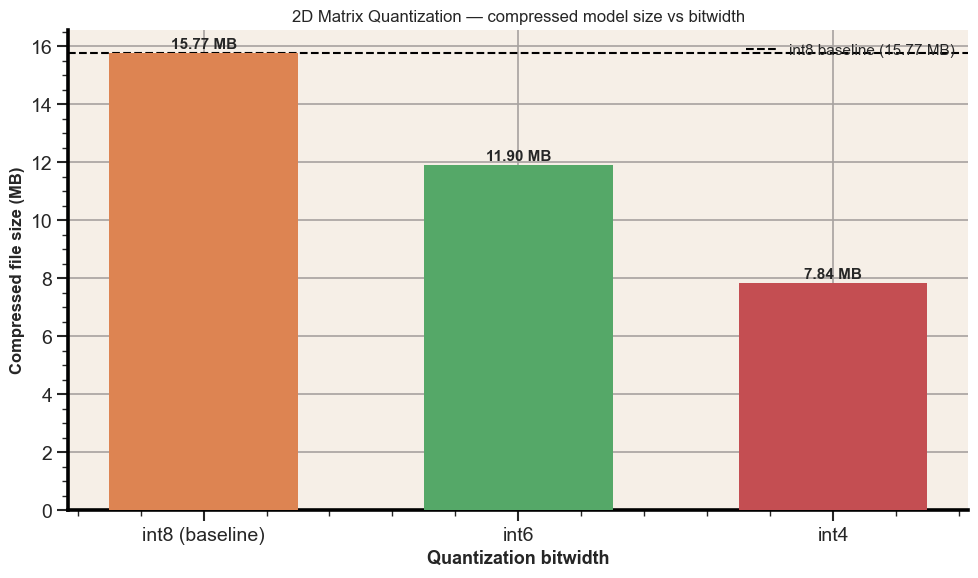

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))

bits_vals = [b for b in BITS_ORDER if b in df["matrix_quant_bits"].values]
size_mb   = [df.loc[df["matrix_quant_bits"] == b, "quant_file_bytes"].values[0] / 1e6
             for b in bits_vals]
colors    = [BITS_COLORS[b] for b in bits_vals]

ax.bar(range(len(bits_vals)), size_mb, color=colors, width=0.6, zorder=3)

for i, (b, mb) in enumerate(zip(bits_vals, size_mb)):
    ax.text(i, mb + 0.05, f"{mb:.2f} MB", ha="center", va="bottom",
            fontsize=11, fontweight="bold")

# baseline int8 reference line
if 8 in df["matrix_quant_bits"].values:
    int8_mb = df.loc[df["matrix_quant_bits"] == 8, "quant_file_bytes"].values[0] / 1e6
    ax.axhline(int8_mb, color="black", linewidth=1.5, linestyle="--",
               label=f"int8 baseline ({int8_mb:.2f} MB)")

ax.set_xticks(range(len(bits_vals)))
ax.set_xticklabels([BITS_LABELS[b] for b in bits_vals])
ax.set_xlabel("Quantization bitwidth", fontsize=13, fontweight="bold")
ax.set_ylabel("Compressed file size (MB)", fontsize=12)
ax.set_title("2D Matrix Quantization — compressed model size vs bitwidth", fontsize=12)
ax.legend(fontsize=11, loc="upper right")
plt.tight_layout(pad=1.5)
plt.show()

### Round-trip BPB vs bitwidth

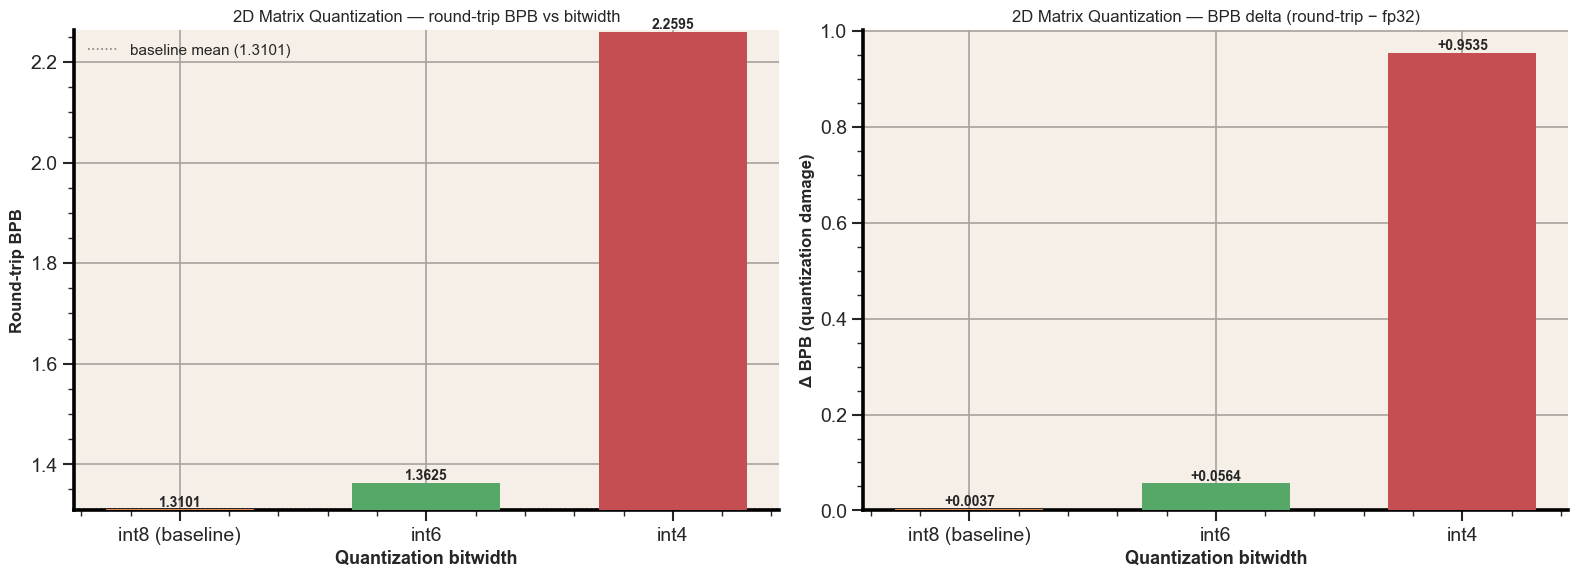

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

bits_vals = [b for b in BITS_ORDER if b in df["matrix_quant_bits"].values]
roundtrip = [df.loc[df["matrix_quant_bits"] == b, "final_val_bpb"].values[0]
             for b in bits_vals]
deltas    = [df.loc[df["matrix_quant_bits"] == b, "delta_bpb"].values[0]
             for b in bits_vals]
colors    = [BITS_COLORS[b] for b in bits_vals]

# --- Round-trip BPB ---
ax = axes[0]
ax.bar(range(len(bits_vals)), roundtrip, color=colors, width=0.6, zorder=3)

for i, (b, bpb) in enumerate(zip(bits_vals, roundtrip)):
    ax.text(i, bpb + 0.0005, f"{bpb:.4f}", ha="center", va="bottom",
            fontsize=10, fontweight="bold")

ax.axhline(BASE_BPB_MEAN, color="grey", linewidth=1.2, linestyle=":",
           label=f"baseline mean ({BASE_BPB_MEAN:.4f})")
ax.set_xticks(range(len(bits_vals)))
ax.set_xticklabels([BITS_LABELS[b] for b in bits_vals])
ax.set_xlabel("Quantization bitwidth", fontsize=13, fontweight="bold")
ax.set_ylabel("Round-trip BPB", fontsize=12)
ax.set_title("2D Matrix Quantization — round-trip BPB vs bitwidth", fontsize=12)
ax.legend(fontsize=11)

# Tight y-axis around the data
ymin = min(roundtrip) - 0.002
ymax = max(roundtrip) + 0.004
ax.set_ylim(ymin, ymax)

# --- Delta (quantization damage) ---
ax = axes[1]
ax.bar(range(len(bits_vals)), deltas, color=colors, width=0.6, zorder=3)

for i, (b, d) in enumerate(zip(bits_vals, deltas)):
    ax.text(i, d + 0.0003, f"{d:+.4f}", ha="center", va="bottom",
            fontsize=10, fontweight="bold")

ax.axhline(0.0, color="grey", linewidth=1.2, linestyle=":")
ax.set_xticks(range(len(bits_vals)))
ax.set_xticklabels([BITS_LABELS[b] for b in bits_vals])
ax.set_xlabel("Quantization bitwidth", fontsize=13, fontweight="bold")
ax.set_ylabel("Δ BPB (quantization damage)", fontsize=12)
ax.set_title("2D Matrix Quantization — BPB delta (round-trip − fp32)", fontsize=12)

plt.tight_layout(pad=1.5)
plt.show()

### Tradeoff: BPB vs compressed size

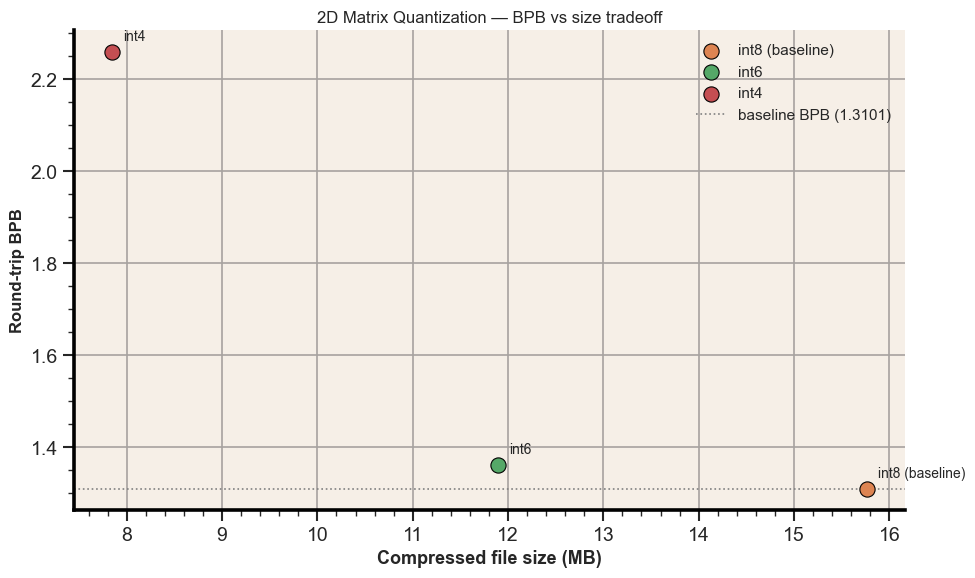

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))

for b in bits_vals:
    row = df[df["matrix_quant_bits"] == b].iloc[0]
    ax.scatter(row["quant_file_bytes"] / 1e6, row["final_val_bpb"],
               color=BITS_COLORS[b], s=120, zorder=5,
               label=BITS_LABELS[b], edgecolors="black", linewidth=0.8)
    ax.annotate(BITS_LABELS[b],
                (row["quant_file_bytes"] / 1e6, row["final_val_bpb"]),
                textcoords="offset points", xytext=(8, 8), fontsize=10)

ax.axhline(BASE_BPB_MEAN, color="grey", linewidth=1.2, linestyle=":",
           label=f"baseline BPB ({BASE_BPB_MEAN:.4f})")

ax.set_xlabel("Compressed file size (MB)", fontsize=13, fontweight="bold")
ax.set_ylabel("Round-trip BPB", fontsize=12)
ax.set_title("2D Matrix Quantization — BPB vs size tradeoff", fontsize=12)
ax.legend(fontsize=11, loc="upper right")
plt.tight_layout(pad=1.5)
plt.show()

### Summary table

In [7]:
rows_summary = [{
    "config":          "Original baseline (3 seeds)",
    "val_bpb":         BASE_BPB_MEAN,
    "val_bpb_std":     BASE_BPB_STD,
    "Δ vs int8":       0.0,
    "file_size_MB":    float("nan"),
}]

int8_bpb = df.loc[df["matrix_quant_bits"] == 8, "final_val_bpb"].values[0] \
           if 8 in df["matrix_quant_bits"].values else BASE_BPB_MEAN

for b in BITS_ORDER:
    sub = df[df["matrix_quant_bits"] == b]
    if sub.empty:
        continue
    row = sub.iloc[0]
    rows_summary.append({
        "config":        BITS_LABELS[b],
        "val_bpb":       row["final_val_bpb"],
        "val_bpb_std":   float("nan"),
        "Δ vs int8":     row["final_val_bpb"] - int8_bpb,
        "file_size_MB":  row["quant_file_bytes"] / 1e6,
    })

df_summary = pd.DataFrame(rows_summary)
df_summary["val_bpb"]      = df_summary["val_bpb"].map(lambda x: f"{x:.4f}")
df_summary["val_bpb_std"]  = df_summary["val_bpb_std"].map(lambda x: f"±{x:.4f}" if not np.isnan(x) else "—")
df_summary["Δ vs int8"]    = df_summary["Δ vs int8"].map(lambda x: f"{x:+.4f}")
df_summary["file_size_MB"] = df_summary["file_size_MB"].map(lambda x: f"{x:.2f}" if not np.isnan(x) else "—")

print(df_summary.to_string(index=False))

# Conclusion
if not df.empty:
    best = df.loc[df["final_val_bpb"].idxmin()]
    print(f"\nBest round-trip BPB: {best['final_val_bpb']:.4f} "
          f"at {BITS_LABELS[best['matrix_quant_bits']]} "
          f"({best['quant_file_bytes'] / 1e6:.2f} MB)")
    print(f"Smallest file: "
          f"{df.loc[df['quant_file_bytes'].idxmin(), 'quant_file_bytes'] / 1e6:.2f} MB "
          f"at {BITS_LABELS[df.loc[df['quant_file_bytes'].idxmin(), 'matrix_quant_bits']]}")

                     config val_bpb val_bpb_std Δ vs int8 file_size_MB
Original baseline (3 seeds)  1.3101     ±0.0013   +0.0000            —
            int8 (baseline)  1.3101           —   +0.0000        15.77
                       int6  1.3625           —   +0.0524        11.90
                       int4  2.2595           —   +0.9493         7.84

Best round-trip BPB: 1.3091 at int8 (baseline) (15.79 MB)
Smallest file: 7.84 MB at int4


In [ ]:
model = GPT(GPTConfig())
state_dict = model.state_dict()

small_bytes = 0
large_2d_bytes = 0
control_bytes = 0

CONTROL_PATTERNS = ["attn_scale", "mlp_scale", "resid_mix", "q_gain", "skip_weights"]

for name, t in state_dict.items():
    nbytes = t.numel() * t.element_size()
    is_control = any(p in name for p in CONTROL_PATTERNS)
    
    if is_control:
        control_bytes += nbytes
    elif t.numel() <= 65536:
        small_bytes += nbytes
    else:
        large_2d_bytes += nbytes

total = small_bytes + large_2d_bytes + control_bytes
print(f"Large 2D matrices: {large_2d_bytes / 1e6:.2f} MB ({100 * large_2d_bytes / total:.1f}%)")
print(f"Small tensors:     {small_bytes / 1e6:.2f} MB ({100 * small_bytes / total:.1f}%)")
print(f"Control tensors:   {control_bytes / 1e6:.2f} MB ({100 * control_bytes / total:.1f}%)")
print(f"Total:             {total / 1e6:.2f} MB")